In [17]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import pymaid
from scipy.stats import wilcoxon
import seaborn as sns
import subprocess
subprocess.run(["pip", "install", "statsmodels", "--quiet"], check=True)
from statsmodels.stats.power import TTestPower
import math 

GABA_THRESHOLD = 40
MATCH_THRESHOLD = 350
ALPHA = 0.05
base_path = os.path.expanduser("~/Downloads/")



In [ ]:
seymour_rm = pymaid.CatmaidInstance(
    server="https://neurophyla.mrc-lmb.cam.ac.uk/catmaid/drosophila/l1/seymour/",
    api_token='',
    http_user='',
    http_password='',
)

gaba_rm = pymaid.CatmaidInstance(
    server="https://neurophyla.mrc-lmb.cam.ac.uk/catmaid/fibsem/",
    api_token='',
    http_user='',
    http_password='',
    project_id=,
)
# api_token='your_token',
    # http_user='your_username',
    # http_password='your_password',

INFO  : Global CATMAID instance set. Caching is ON. (pymaid)
INFO  : Global CATMAID instance set. Caching is ON. (pymaid)


In [19]:
soma_locs = pd.read_csv(f"{base_path}soma_locs.csv")
print(f"Loaded {len(soma_locs)} neurons")

Loaded 2014 neurons


In [20]:
fluo = np.load(f"{base_path}smallROIFluorescence_values_raw_5x5x1.npy")
fluo[:, 0] = fluo[:, 0] * 32
fluo[:, 1] = fluo[:, 1] * 32
fluo[:, 2] = fluo[:, 2] * 32

In [21]:
# Fetch from gaba_rm instead
ns_damd1_L = pymaid.find_neurons(annotations=["DAMd1 L"], remote_instance=gaba_rm)
ns_damd1_R = pymaid.find_neurons(annotations=["DAMd1 R"], remote_instance=gaba_rm)

skids_L = list(ns_damd1_L.skeleton_id)
skids_R = list(ns_damd1_R.skeleton_id)

print(f"DAMd1 L: {len(skids_L)} neurons -> skids: {skids_L}")
print(f"DAMd1 R: {len(skids_R)} neurons -> skids: {skids_R}")

#finds neurons annotated with DAMd1 L/R in the GABA volume and then retrieves their skids and prints them as a list 

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


Make nrn:   0%|          | 0/6 [00:00<?, ?it/s]

INFO  : Found 6 neurons matching the search parameters (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


Make nrn:   0%|          | 0/6 [00:00<?, ?it/s]

INFO  : Found 6 neurons matching the search parameters (pymaid)


DAMd1 L: 6 neurons -> skids: [np.str_('44396000'), np.str_('13889'), np.str_('44394901'), np.str_('13883'), np.str_('44395977'), np.str_('44396235')]
DAMd1 R: 6 neurons -> skids: [np.str_('20480'), np.str_('20496'), np.str_('20474'), np.str_('20490'), np.str_('20486'), np.str_('20506')]


In [22]:
all_skids = skids_L + skids_R
all_annots = pymaid.get_annotations(all_skids, remote_instance=gaba_rm)
print(all_annots)

#combines the skids of L and R neurons, fetches the annotations for each neuron

{'13883': ['BRAIN', 'left', 'DAMd1 L', 'MBON-i1', '7802210'], '13889': ['BRAIN', 'left', 'DAMd1 L'], '20474': ['BRAIN', 'lep3', 'right', 'left', 'MBON-e2', '8297018', 'DAMd1 R'], '20480': ['BRAIN', 'lep3', 'right', 'DAMd1 R', 'MBON-d3', '9074101'], '20486': ['BRAIN', 'lep3', 'DAMd1 R', 'MBON-k1', '18028397'], '20490': ['BRAIN', 'lep3', 'right', '3299214', 'MBON-j1', 'DAMd1 R'], '20496': ['BRAIN', 'right', 'lep3', 'DAM', 'MBON-i1', 'DAMd1 R', '16797672'], '20506': ['BRAIN', 'lep3', 'DAMd1 R', '18035864'], '44394901': ['DAMd1 L', 'MBON-d3', '9109799'], '44395977': ['DAMd1 L', 'MBON-e2', '8922644'], '44396000': ['DAMd1 L', 'MBON-j1', '15421363'], '44396235': ['DAMd1 L', 'MBON-k1', '16846805']}


In [23]:
records = []
for skid, annots in all_annots.items():
    mbon = next((a.strip() for a in annots if a.strip().startswith('MBON-')), None)
    side = 'L' if str(skid) in [str(s) for s in skids_L] else 'R'
    seymour_skid = next((a.strip() for a in annots if a.strip().isdigit()), None)
    if mbon:
        records.append({'skid': skid, 'mbon': mbon, 'side': side, 'seymour_skid': seymour_skid})

annots_df = pd.DataFrame(records)
print(annots_df)

#for each skid, it gives the skid followed by the list of annotations
#runs through the annotation list and fetches the first annotation that begins with MBON- (this can be changed for different lineages)
#checks whether this neuron is on the L/R side 
#returns the seymour_skid
#if an MBON annotation was found, then adds it to the list and then finally converts into a dataframe


       skid     mbon side seymour_skid
0     13883  MBON-i1    L      7802210
1     20474  MBON-e2    R      8297018
2     20480  MBON-d3    R      9074101
3     20486  MBON-k1    R     18028397
4     20490  MBON-j1    R      3299214
5     20496  MBON-i1    R     16797672
6  44394901  MBON-d3    L      9109799
7  44395977  MBON-e2    L      8922644
8  44396000  MBON-j1    L     15421363
9  44396235  MBON-k1    L     16846805


In [24]:
soma_locs_damd1 = soma_locs[soma_locs['skid'].astype(str).isin([str(s) for s in all_skids])].copy()


In [25]:
# ── Fluorescence assignment ──────────────────────────────────────────────────
soma_locs_damd1 = soma_locs[soma_locs['skid'].astype(str).isin([str(s) for s in all_skids])].copy()
em_coords = soma_locs_damd1[['x_raw', 'y_raw', 'z_raw']].values
fluo_df = pd.DataFrame(fluo[:, [2,1,0,3]], columns=['x','y','z','fluorescence'])

from scipy.spatial import cKDTree
tree = cKDTree(fluo_df[['x', 'y', 'z']].values)
d, idx = tree.query(em_coords)

soma_locs_damd1['fluorescence']      = fluo_df.iloc[idx]['fluorescence'].values
soma_locs_damd1['closest_fluo_dist'] = d

soma_locs_damd1['match_ok'] = soma_locs_damd1['closest_fluo_dist'] < MATCH_THRESHOLD
bad = soma_locs_damd1[~soma_locs_damd1['match_ok']]
if len(bad):
    print(f"WARNING: {len(bad)} poor matches — consider excluding:")
    print(bad[['skid', 'closest_fluo_dist']])

print(soma_locs_damd1[['skid', 'fluorescence', 'closest_fluo_dist']])

          skid  fluorescence  closest_fluo_dist
0        20480         44.80          64.896870
2        20486         10.68          78.630369
6        20490         62.12          58.511166
9        20496         94.48          33.009379
14       20506         23.40          37.003378
847      13883         27.40          39.333878
851      13889         29.24          36.560400
1259  44394901         25.40          29.253063
1714  44395977         45.84          44.325111
1727  44396000         61.72         135.335961
1855  44396235         60.12          38.207917
2011     20474         47.36          23.502167


In [26]:
# Rebuild lr_pairs_df with new fluorescence values
lr_pairs_df = annots_df.pivot(index='mbon', columns='side', values=['skid', 'seymour_skid']).reset_index()
lr_pairs_df.columns = ['mbon', 'skid_L', 'skid_R', 'seymour_skid_L', 'seymour_skid_R']

lr_pairs_df['skid_L'] = lr_pairs_df['skid_L'].astype(str)
lr_pairs_df['skid_R'] = lr_pairs_df['skid_R'].astype(str)
soma_locs_damd1['skid'] = soma_locs_damd1['skid'].astype(str)

lr_pairs_df = lr_pairs_df.merge(
    soma_locs_damd1[['skid', 'fluorescence', 'closest_fluo_dist']]
        .rename(columns={'skid': 'skid_L', 'fluorescence': 'fluo_L',
                         'closest_fluo_dist': 'dist_L'}),
    on='skid_L', how='left'
).merge(
    soma_locs_damd1[['skid', 'fluorescence', 'closest_fluo_dist']]
        .rename(columns={'skid': 'skid_R', 'fluorescence': 'fluo_R',
                         'closest_fluo_dist': 'dist_R'}),
    on='skid_R', how='left'
)

print(lr_pairs_df[['mbon', 'fluo_L', 'fluo_R']])


#matches skids from the soma locations csv file created in the fluorescence script, and appends their fluorescence value for both the right and left homologue of the MBON


      mbon  fluo_L  fluo_R
0  MBON-d3   25.40   44.80
1  MBON-e2   45.84   47.36
2  MBON-i1   27.40   94.48
3  MBON-j1   61.72   62.12
4  MBON-k1   60.12   10.68


In [27]:
from scipy.stats import shapiro

# Shapiro-Wilk uses lr_pairs_df and fluo_L/fluo_R (consistent with rest of script)
valid_sw = lr_pairs_df.dropna(subset=['fluo_L', 'fluo_R']).copy()
valid_sw['delta'] = valid_sw['fluo_L'] - valid_sw['fluo_R']

stat_L, p_L = shapiro(valid_sw['fluo_L'])
stat_R, p_R = shapiro(valid_sw['fluo_R'])
stat_delta, p_delta = shapiro(valid_sw['delta'])

print("=" * 40)
print("Shapiro-Wilk Normality Tests")
print(f"  fluo_L: W = {stat_L:.3f}, p = {p_L:.4f} {'NORMAL' if p_L > 0.05 else 'NON-NORMAL'}")
print(f"  fluo_R: W = {stat_R:.3f}, p = {p_R:.4f} {'NORMAL' if p_R > 0.05 else 'NON-NORMAL'}")
print(f"  delta:  W = {stat_delta:.3f}, p = {p_delta:.4f} {'NORMAL' if p_delta > 0.05 else 'NON-NORMAL'}")
print("=" * 40)

Shapiro-Wilk Normality Tests
  fluo_L: W = 0.856, p = 0.2150 NORMAL
  fluo_R: W = 0.972, p = 0.8895 NORMAL
  delta:  W = 0.959, p = 0.7984 NORMAL


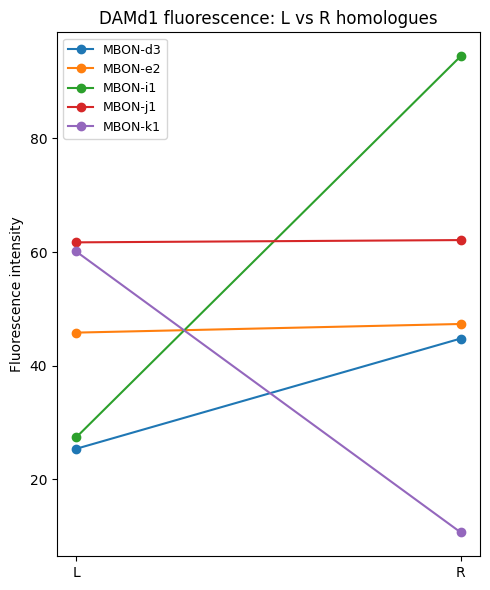

In [28]:
fig, ax = plt.subplots(figsize=(5, 6))

for _, row in lr_pairs_df.iterrows():
    ax.plot(['L', 'R'], [row.fluo_L, row.fluo_R], 'o-', label=row.mbon)
    
ax.set_ylabel("Fluorescence intensity")
ax.set_title("DAMd1 fluorescence: L vs R homologues")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(base_path, "DAMd1_LR_fluorescence.pdf"), bbox_inches='tight')
plt.show()


In [29]:
print(soma_locs_damd1[['skid', 'fluorescence', 'closest_fluo_dist']].sort_values('closest_fluo_dist', ascending=False))


          skid  fluorescence  closest_fluo_dist
1727  44396000         61.72         135.335961
2        20486         10.68          78.630369
0        20480         44.80          64.896870
6        20490         62.12          58.511166
1714  44395977         45.84          44.325111
847      13883         27.40          39.333878
1855  44396235         60.12          38.207917
14       20506         23.40          37.003378
851      13889         29.24          36.560400
9        20496         94.48          33.009379
1259  44394901         25.40          29.253063
2011     20474         47.36          23.502167



GABA classification (threshold = 40 AU):
      mbon  fluo_L  fluo_R  gaba_L  gaba_R  agreement
0  MBON-d3   25.40   44.80   False    True      False
1  MBON-e2   45.84   47.36    True    True       True
2  MBON-i1   27.40   94.48   False    True      False
3  MBON-j1   61.72   62.12    True    True       True
4  MBON-k1   60.12   10.68    True   False      False
L/R agreement: 2/5 pairs (40%)
  n pairs         : 5
  Mean fluo L     : 44.0960 ± 17.3112
  Mean fluo R     : 51.8880 ± 30.3629
  Mean delta (L-R): -7.7920
----------------------------------------
  Paired t-test   : t = -0.416,  p = 0.6988
  Wilcoxon test   : W = 4.0,  p = 0.4375

Paired t-test conclusion  : NOT significant (p=0.6988)
Wilcoxon conclusion       : NOT significant (p=0.4375)
(Primary test: paired t-test — normality not rejected by Shapiro-Wilk, delta W=0.959, p=0.7984)


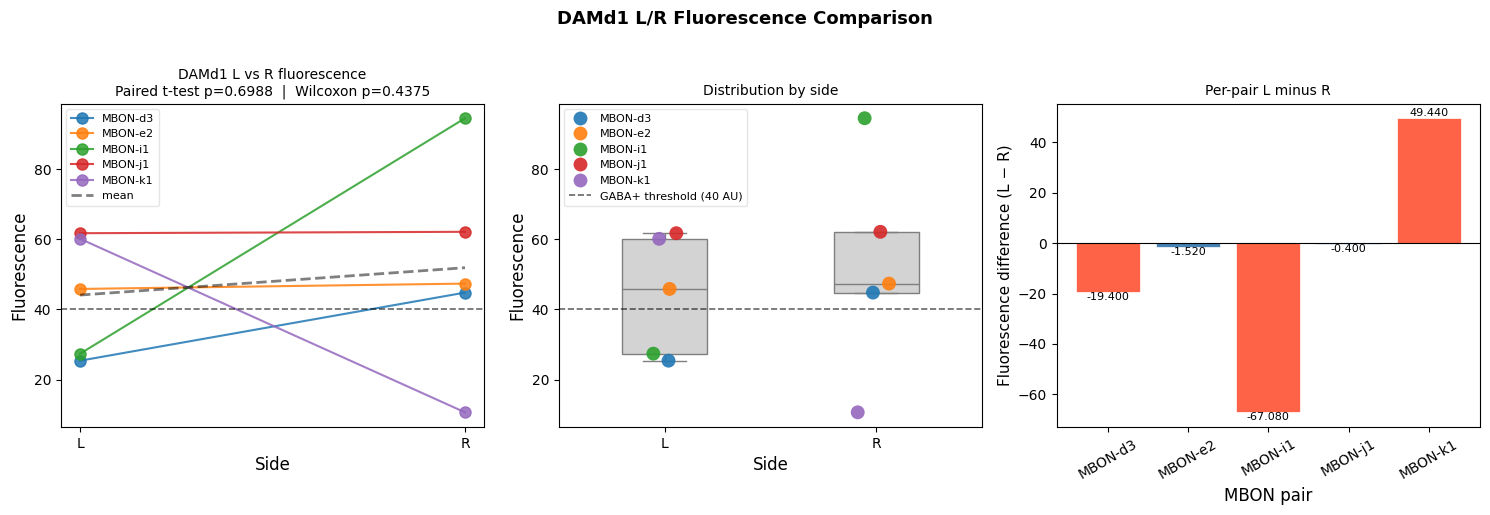

Observed power at n=5: 9.5%
n required for 80% power (d=0.5): 34


In [31]:
from scipy import stats

valid = lr_pairs_df.dropna(subset=['fluo_L', 'fluo_R']).copy()
valid['delta'] = valid.fluo_L - valid.fluo_R

valid['gaba_L']    = valid['fluo_L'] >= GABA_THRESHOLD
valid['gaba_R']    = valid['fluo_R'] >= GABA_THRESHOLD
valid['agreement'] = valid['gaba_L'] == valid['gaba_R']

print("\nGABA classification (threshold = 40 AU):")
print(valid[['mbon', 'fluo_L', 'fluo_R', 'gaba_L', 'gaba_R', 'agreement']])
n_agree = valid['agreement'].sum()
print(f"L/R agreement: {n_agree}/{len(valid)} pairs ({100*n_agree/len(valid):.0f}%)")

n = len(valid)
mean_L = valid.fluo_L.mean()
mean_R = valid.fluo_R.mean()
std_L  = valid.fluo_L.std()
std_R  = valid.fluo_R.std()

t_stat, p_ttest = stats.ttest_rel(valid.fluo_L, valid.fluo_R)

if n >= 5:
    w_stat, p_wilcoxon = stats.wilcoxon(valid.fluo_L, valid.fluo_R)
else:
    w_stat, p_wilcoxon = np.nan, np.nan
    print(f"Note: n={n} is below minimum of 5 for Wilcoxon test")

print("=" * 40)
print(f"  n pairs         : {n}")
print(f"  Mean fluo L     : {mean_L:.4f} ± {std_L:.4f}")
print(f"  Mean fluo R     : {mean_R:.4f} ± {std_R:.4f}")
print(f"  Mean delta (L-R): {valid.delta.mean():.4f}")
print("-" * 40)
print(f"  Paired t-test   : t = {t_stat:.3f},  p = {p_ttest:.4f}")
print(f"  Wilcoxon test   : W = {w_stat},  p = {p_wilcoxon:.4f}")
print("=" * 40)

sig_ttest    = p_ttest < ALPHA
sig_wilcoxon = p_wilcoxon < ALPHA
print(f"\nPaired t-test conclusion  : {'SIGNIFICANT' if sig_ttest else 'NOT significant'} (p={p_ttest:.4f})")
print(f"Wilcoxon conclusion       : {'SIGNIFICANT' if sig_wilcoxon else 'NOT significant'} (p={p_wilcoxon:.4f})")
print(f"(Primary test: paired t-test — normality not rejected by Shapiro-Wilk, delta W={stat_delta:.3f}, p={p_delta:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = plt.cm.tab10.colors

ax = axes[0]
for i, (_, row) in enumerate(valid.iterrows()):
    ax.plot(['L', 'R'], [row.fluo_L, row.fluo_R],
            'o-', color=colors[i % 10], alpha=0.85,
            linewidth=1.5, markersize=8, label=row.mbon)
ax.plot(['L', 'R'], [mean_L, mean_R], 'k--', linewidth=2, alpha=0.5, label='mean')
ax.set_ylabel("Fluorescence", fontsize=12)
ax.set_xlabel("Side", fontsize=12)
ax.set_title(f"DAMd1 L vs R fluorescence\nPaired t-test p={p_ttest:.4f}  |  Wilcoxon p={p_wilcoxon:.4f}", fontsize=10)
ax.legend(fontsize=8, framealpha=0.5)
ax.axhline(GABA_THRESHOLD, color='black', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'GABA+ threshold ({GABA_THRESHOLD} AU)')


ax = axes[1]
long = pd.melt(valid, id_vars='mbon', value_vars=['fluo_L', 'fluo_R'], var_name='side', value_name='fluorescence')
long['side'] = long.side.map({'fluo_L': 'L', 'fluo_R': 'R'})
sns.boxplot(data=long, x='side', y='fluorescence', order=['L', 'R'], ax=ax, width=0.4, color='lightgray', fliersize=0)
sns.stripplot(data=long, x='side', y='fluorescence', order=['L', 'R'], hue='mbon', ax=ax, size=10, alpha=0.9, palette=colors[:len(valid)])
ax.axhline(GABA_THRESHOLD, color='black', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'GABA+ threshold ({GABA_THRESHOLD} AU)')
ax.set_title("Distribution by side", fontsize=10)
ax.set_ylabel("Fluorescence", fontsize=12)
ax.set_xlabel("Side", fontsize=12)
ax.legend(fontsize=8, framealpha=0.5)

ax = axes[2]
bar_colors = ['steelblue' if row.agreement else 'tomato' for _, row in valid.iterrows()]
bars = ax.bar(valid.mbon, valid.delta, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel("MBON pair", fontsize=12)
ax.set_ylabel("Fluorescence difference (L − R)", fontsize=11)
ax.set_title("Per-pair L minus R", fontsize=10)
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, valid.delta):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (0.002 if val > 0 else -0.004),
            f"{val:.3f}", ha='center',
            va='bottom' if val > 0 else 'top', fontsize=8)

plt.suptitle("DAMd1 L/R Fluorescence Comparison", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(base_path, "DAMd1_LR_fluorescence.pdf"), bbox_inches='tight')
plt.show()

# --- Power Analysis (scipy only, no statsmodels required) ---
def paired_ttest_power(effect_size, n, alpha=0.05):
    from scipy.stats import t
    import math
    df = n - 1
    ncp = effect_size * math.sqrt(n)
    t_crit = t.ppf(1 - alpha / 2, df)
    power = 1 - t.cdf(t_crit, df, loc=ncp) + t.cdf(-t_crit, df, loc=ncp)
    return power

def n_for_power(effect_size, target_power=0.80, alpha=0.05, max_n=500):
    for n in range(2, max_n):
        if paired_ttest_power(effect_size, n, alpha) >= target_power:
            return n

observed_power = paired_ttest_power(0.5, len(valid))
n_required = n_for_power(0.5)

print(f"Observed power at n={len(valid)}: {observed_power:.1%}")
print(f"n required for 80% power (d=0.5): {n_required}")


In [ ]:
#cut off for +ve GABA = 40 - need to take that into consideration and then give reasons for it, would expect L/R to show the same but it doesn't

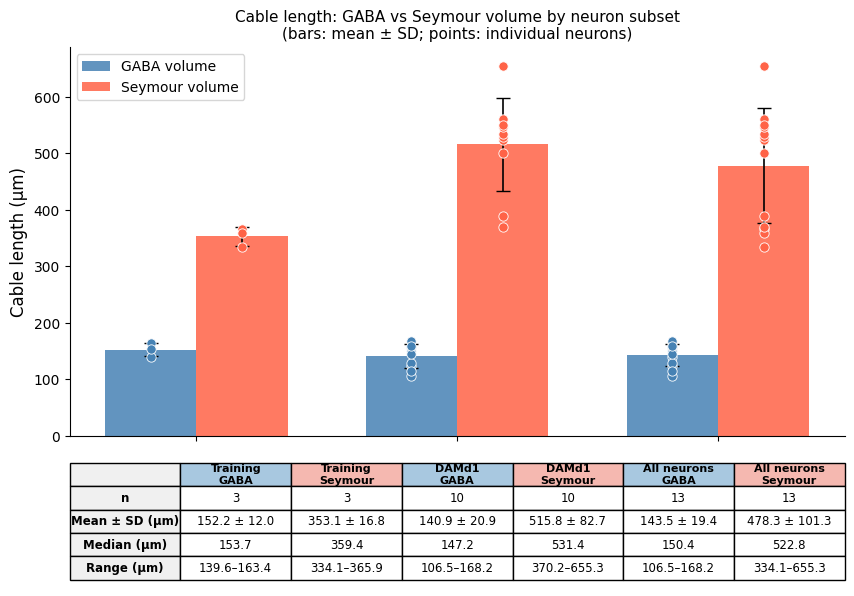

In [39]:
# ── Cable Length Bar Chart with summary stats table ───────────────────────────

groups    = ['Training', 'DAMd1', 'All neurons']
x         = np.arange(len(groups))
bar_width = 0.35

subsets = {
    'Training':    all_neurons[all_neurons['group'] == 'Training'],
    'DAMd1':       all_neurons[all_neurons['group'] == 'DAMd1'],
    'All neurons': all_neurons,
}

# Compute stats per group × volume
stats = {}
for grp in groups:
    sub = subsets[grp].dropna(subset=['cable_gaba_um', 'cable_seymour_um'])
    stats[grp] = {
        'gaba':    {'n': len(sub),
                    'mean': sub.cable_gaba_um.mean(),
                    'sd':   sub.cable_gaba_um.std(ddof=1),
                    'med':  sub.cable_gaba_um.median(),
                    'min':  sub.cable_gaba_um.min(),
                    'max':  sub.cable_gaba_um.max()},
        'seymour': {'n': len(sub),
                    'mean': sub.cable_seymour_um.mean(),
                    'sd':   sub.cable_seymour_um.std(ddof=1),
                    'med':  sub.cable_seymour_um.median(),
                    'min':  sub.cable_seymour_um.min(),
                    'max':  sub.cable_seymour_um.max()},
    }

gaba_means    = [stats[g]['gaba']['mean']    for g in groups]
gaba_sds      = [stats[g]['gaba']['sd']      for g in groups]
seymour_means = [stats[g]['seymour']['mean'] for g in groups]
seymour_sds   = [stats[g]['seymour']['sd']   for g in groups]

# ── Figure: bar chart + stats table ──────────────────────────────────────────
fig = plt.figure(figsize=(10, 7))
gs  = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
ax  = fig.add_subplot(gs[0])
ax_table = fig.add_subplot(gs[1])
ax_table.axis('off')

# Bars
bars_g = ax.bar(x - bar_width/2, gaba_means, bar_width,
                yerr=gaba_sds, capsize=5,
                color='steelblue', alpha=0.85, label='GABA volume',
                error_kw={'linewidth': 1.2})
bars_s = ax.bar(x + bar_width/2, seymour_means, bar_width,
                yerr=seymour_sds, capsize=5,
                color='tomato', alpha=0.85, label='Seymour volume',
                error_kw={'linewidth': 1.2})

# Individual points
for i, grp in enumerate(groups):
    sub = subsets[grp].dropna(subset=['cable_gaba_um', 'cable_seymour_um'])
    ax.scatter(np.full(len(sub), x[i] - bar_width/2), sub.cable_gaba_um,
               color='steelblue', edgecolors='white', s=45, zorder=5, lw=0.6)
    ax.scatter(np.full(len(sub), x[i] + bar_width/2), sub.cable_seymour_um,
               color='tomato', edgecolors='white', s=45, zorder=5, lw=0.6)

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=12)
ax.set_ylabel('Cable length (μm)', fontsize=12)
ax.set_title('Cable length: GABA vs Seymour volume by neuron subset\n(bars: mean ± SD; points: individual neurons)',
             fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, None)
ax.set_xticklabels([])   # labels replaced by table below
sns.despine(ax=ax)

# ── Summary stats table ───────────────────────────────────────────────────────
col_labels = ['', 'Training\nGABA', 'Training\nSeymour',
              'DAMd1\nGABA', 'DAMd1\nSeymour',
              'All neurons\nGABA', 'All neurons\nSeymour']

row_labels = ['n', 'Mean ± SD (μm)', 'Median (μm)', 'Range (μm)']

table_data = [
    # n
    ['',
     f"{stats['Training']['gaba']['n']}",
     f"{stats['Training']['seymour']['n']}",
     f"{stats['DAMd1']['gaba']['n']}",
     f"{stats['DAMd1']['seymour']['n']}",
     f"{stats['All neurons']['gaba']['n']}",
     f"{stats['All neurons']['seymour']['n']}"],
    # mean ± SD
    ['',
     f"{stats['Training']['gaba']['mean']:.1f} ± {stats['Training']['gaba']['sd']:.1f}",
     f"{stats['Training']['seymour']['mean']:.1f} ± {stats['Training']['seymour']['sd']:.1f}",
     f"{stats['DAMd1']['gaba']['mean']:.1f} ± {stats['DAMd1']['gaba']['sd']:.1f}",
     f"{stats['DAMd1']['seymour']['mean']:.1f} ± {stats['DAMd1']['seymour']['sd']:.1f}",
     f"{stats['All neurons']['gaba']['mean']:.1f} ± {stats['All neurons']['gaba']['sd']:.1f}",
     f"{stats['All neurons']['seymour']['mean']:.1f} ± {stats['All neurons']['seymour']['sd']:.1f}"],
    # median
    ['',
     f"{stats['Training']['gaba']['med']:.1f}",
     f"{stats['Training']['seymour']['med']:.1f}",
     f"{stats['DAMd1']['gaba']['med']:.1f}",
     f"{stats['DAMd1']['seymour']['med']:.1f}",
     f"{stats['All neurons']['gaba']['med']:.1f}",
     f"{stats['All neurons']['seymour']['med']:.1f}"],
    # range
    ['',
     f"{stats['Training']['gaba']['min']:.1f}–{stats['Training']['gaba']['max']:.1f}",
     f"{stats['Training']['seymour']['min']:.1f}–{stats['Training']['seymour']['max']:.1f}",
     f"{stats['DAMd1']['gaba']['min']:.1f}–{stats['DAMd1']['gaba']['max']:.1f}",
     f"{stats['DAMd1']['seymour']['min']:.1f}–{stats['DAMd1']['seymour']['max']:.1f}",
     f"{stats['All neurons']['gaba']['min']:.1f}–{stats['All neurons']['gaba']['max']:.1f}",
     f"{stats['All neurons']['seymour']['min']:.1f}–{stats['All neurons']['seymour']['max']:.1f}"],
]

# Populate row label into first column
for i, row in enumerate(table_data):
    row[0] = row_labels[i]

tbl = ax_table.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.4)

# Colour-code header cells to match bars
for col_idx, label in enumerate(col_labels):
    cell = tbl[0, col_idx]
    if 'GABA' in label:
        cell.set_facecolor('#a8c8e0')   # light steelblue
    elif 'Seymour' in label:
        cell.set_facecolor('#f5b8b0')   # light tomato
    else:
        cell.set_facecolor('#f0f0f0')
    cell.set_text_props(fontweight='bold', fontsize=8)

# Row label column bold
for row_idx in range(1, len(row_labels) + 1):
    tbl[row_idx, 0].set_text_props(fontweight='bold')
    tbl[row_idx, 0].set_facecolor('#f0f0f0')

plt.savefig(os.path.join(base_path, 'cable_length_comparison.pdf'),
            bbox_inches='tight')
plt.show()